# RAMP on predicting cyclist traffic in Paris


## Introduction

Dataset collecté avec des compteurs à cyclistes installés par la mairie de Paris. Il contient des informations sur le traffic des cyclistes dans Paris, ainsi que quelques features supplémentaires :
 - counter name
 - counter site name
 - date
 - counter installation date
 - latitude et longitude
 
**Nous allons aussi pouvoir utiliser de la data externe pour aider à prédire la variable cible.** 

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Data loading

La data est au format parquet [Parquet format](https://parquet.apache.org/), un format efficace. On peut charger les données avec Pandas

In [2]:
data = pd.read_parquet(Path.cwd().parent / "data/raw/bikes.parquet")
data.head()

,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,longitude,log_bike_count
48321,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 02:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48324,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,1.0,2020-09-01 03:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.693147
48327,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 04:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48330,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,4.0,2020-09-01 15:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,1.609438
48333,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,9.0,2020-09-01 18:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,2.302585


Informations sur quelques colonnes

In [3]:
data = data.sort_values(["date", "counter_name"])

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496827 entries, 400125 to 135985
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   counter_id                 496827 non-null  category      
 1   counter_name               496827 non-null  category      
 2   site_id                    496827 non-null  int64         
 3   site_name                  496827 non-null  category      
 4   bike_count                 496827 non-null  float64       
 5   date                       496827 non-null  datetime64[us]
 6   counter_installation_date  496827 non-null  datetime64[us]
 7   coordinates                496827 non-null  category      
 8   counter_technical_id       496827 non-null  category      
 9   latitude                   496827 non-null  float64       
 10  longitude                  496827 non-null  float64       
 11  log_bike_count             496827 non-null  float64 

en particulier le nombre d'entrées unique pour chaque colonne

In [5]:
data.nunique(axis=0)

counter_id                     56
counter_name                   56
site_id                        30
site_name                      30
bike_count                    998
date                         8974
counter_installation_date      22
coordinates                    30
counter_technical_id           30
latitude                       30
longitude                      30
log_bike_count                998
dtype: int64

30 localisation différentes, avec parfois plusieurs compteurs. Regardons quelles sont les stations les plus fréquentées:

In [6]:
(
    data.groupby(["site_name", "counter_name"])["bike_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .to_frame()
)

/var/folders/dr/m9v4shms079d9s6z6c8cg57m0000gn/T/ipykernel_3562/1364784656.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["site_name", "counter_name"])["bike_count"]


,,bike_count
site_name,counter_name,
Totem 73 boulevard de Sébastopol,Totem 73 boulevard de Sébastopol S-N,1992227.0
Totem 64 Rue de Rivoli,Totem 64 Rue de Rivoli O-E,1551730.0
Totem 73 boulevard de Sébastopol,Totem 73 boulevard de Sébastopol N-S,1497912.0
67 boulevard Voltaire SE-NO,67 boulevard Voltaire SE-NO,1130565.0
Totem 64 Rue de Rivoli,Totem 64 Rue de Rivoli E-O,1015875.0
27 quai de la Tournelle,27 quai de la Tournelle SE-NO,984914.0
Quai d'Orsay,Quai d'Orsay E-O,948357.0
Totem Cours la Reine,Totem Cours la Reine O-E,894937.0
Face au 48 quai de la marne,Face au 48 quai de la marne SO-NE,884907.0


In [7]:
pip install ydata-profiling


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ydata_profiling import ProfileReport


In [ ]:
ProfileReport(data, title="Data Profiling Report", explorative=True)


# Visualizing the data

In [ ]:
pip install folium

In [16]:
import folium

m = folium.Map(location=data[["latitude", "longitude"]].mean(axis=0), zoom_start=13)

for _, row in (
    data[["counter_name", "latitude", "longitude"]]
    .drop_duplicates("counter_name")
    .iterrows()
):
    folium.Marker(
        row[["latitude", "longitude"]].values.tolist(), popup=row["counter_name"]
    ).add_to(m)

m

/Applications/anaconda3/envs/albert_school/lib/python3.11/site-packages/folium/utilities.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coords = (location[0], location[1])


Regardons la distribution temporelle du compteur le plus fréquenté, attention à ne pas le plot directement, sous peine de ne rien voir.

<Axes: xlabel='date'>

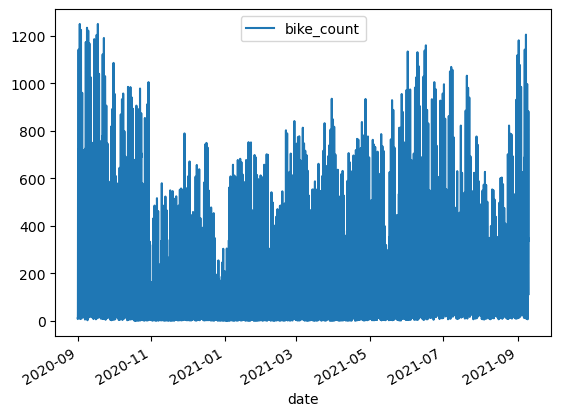

In [8]:
mask = data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N"

data[mask].sort_values(by="date", ascending=True).plot(x="date", y="bike_count")

Aggrégons la donnée, par exemple par semaine

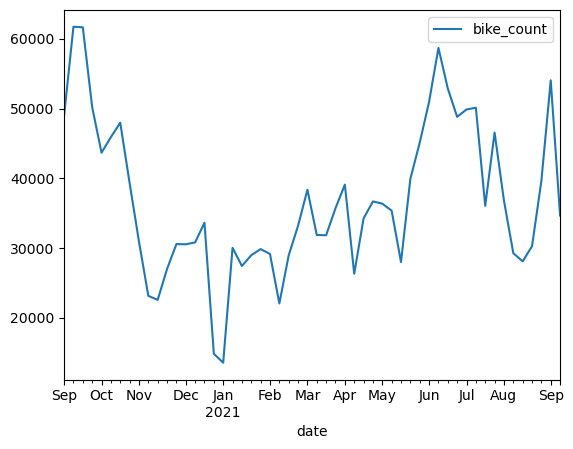

In [9]:
mask = data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N"

data[mask].groupby(pd.Grouper(freq="1W", key="date"))[["bike_count"]].sum().plot();

Ou sur une semaine en particulier

<Axes: xlabel='date'>

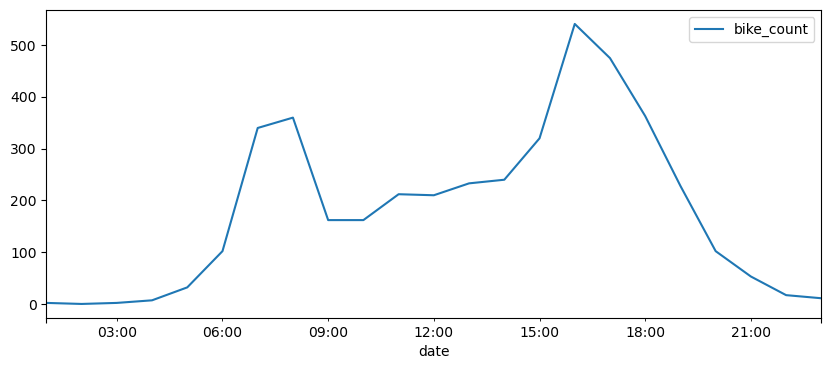

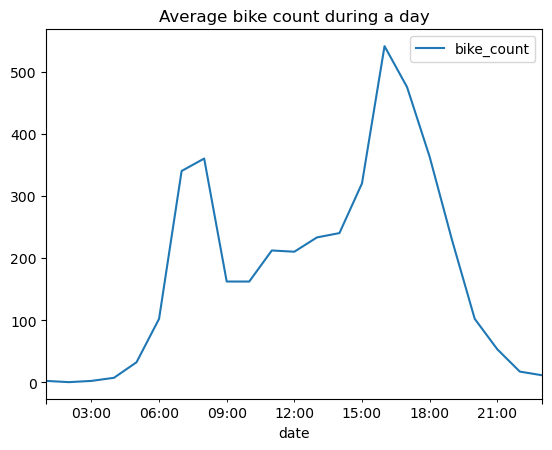

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

mask = (
    (data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N")
    & (data["date"] > pd.to_datetime("2021/02/08"))
    & (data["date"] < pd.to_datetime("2021/02/09"))
)

data[mask].groupby(pd.Grouper(key="date"))[["bike_count"]].sum().plot()
plt.title("Average bike count during a day")
data[mask].plot(x="date", y="bike_count", ax=ax)

On voit une différence marquée au niveau horaire entre semaine et week-end. 

Si on regarde la distribution de notre variable cible, celle-ci est skewed est non normale


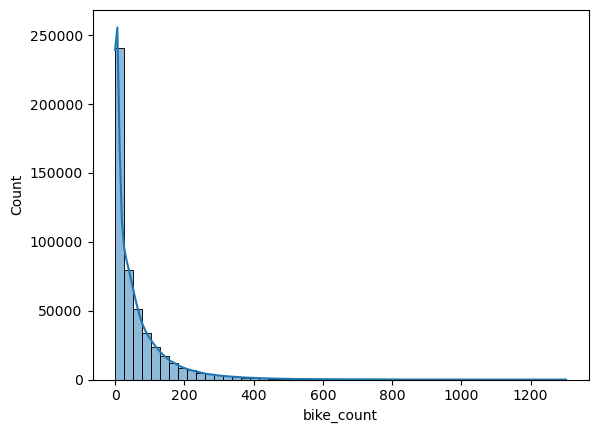

In [11]:
import seaborn as sns


ax = sns.histplot(data, x="bike_count", kde=True, bins=50)

La least square loss ne serait pas appropriée pour modéliser vu qu'on aurait besoin que l'erreur soit distribuée en respectant une loi normale. Essayons une transformation logarithmique pour régler ce problème

```py
data['log_bike_count'] = np.log(1 + data['bike_count'])
```

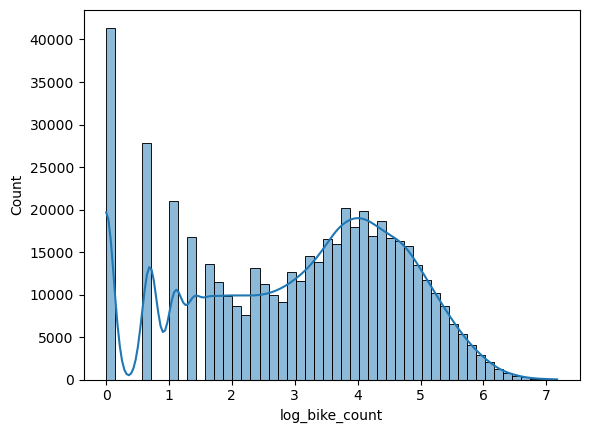

In [12]:
ax = sns.histplot(data, x="log_bike_count", kde=True, bins=50)
plt.savefig("../plots/log_transformed.png")

which has a more pronounced central mode, but is still non symmetric. In the following, **we use `log_bike_count` as the target variable** as otherwise `bike_count` ranges over 3 orders of magnitude and least square loss would be dominated by the few large values. 

## Quid d'une station qui ferme ? 

In [14]:
import pandas as pd
import numpy as np

data_sorted = data.sort_values(["counter_name", "date"]).copy()

data_sorted["zero_group"] = (
    (data_sorted["bike_count"] != 0).cumsum())

data_sorted["is_zero"] = (data_sorted["bike_count"] == 0).astype(int)
consecutive_zeros = data_sorted[data_sorted["is_zero"] == 1]

zero_periods = (
    consecutive_zeros.groupby(["counter_name", "zero_group"])
    .agg(
        consecutive_zero_count=("bike_count", "size"),
        start_date=("date", "min"),
        end_date=("date", "max")
    )
    .reset_index()
)

top_zero_periods = zero_periods.sort_values(by="consecutive_zero_count", ascending=False)

top_zero_periods.head()


/var/folders/dr/m9v4shms079d9s6z6c8cg57m0000gn/T/ipykernel_20603/2330136574.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  consecutive_zeros.groupby(["counter_name", "zero_group"])


,counter_name,zero_group,consecutive_zero_count,start_date,end_date
78025,20 Avenue de Clichy NO-SE,37528,1834,2021-05-05 23:00:00,2021-07-21 08:00:00
97286,20 Avenue de Clichy SE-NO,44150,1832,2021-05-06 01:00:00,2021-07-21 08:00:00
134,152 boulevard du Montparnasse E-O,3304,724,2021-01-25 09:00:00,2021-02-24 13:00:00
19523,152 boulevard du Montparnasse O-E,11195,724,2021-01-25 09:00:00,2021-02-24 13:00:00
77978,20 Avenue de Clichy NO-SE,37367,95,2021-04-15 13:00:00,2021-04-19 11:00:00


Regardons ce qu'il se passe Avenue de Clichy quand une station ferme

<Figure size 1200x600 with 0 Axes>

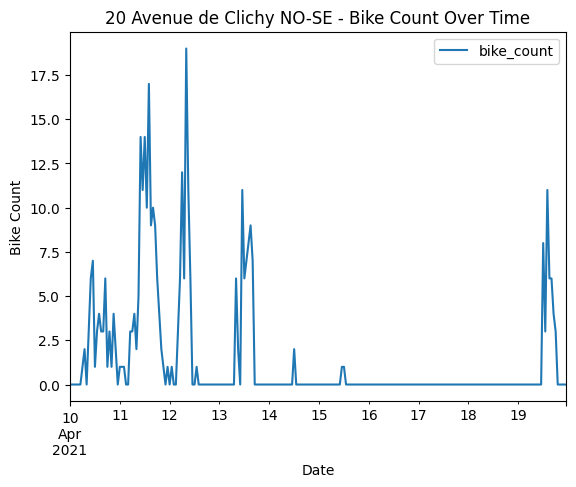

In [15]:
from datetime import datetime

counter_to_inspect = "20 Avenue de Clichy NO-SE"
data.sort_values(["date", "counter_name"])
start_date = datetime(2021, 4, 10)
end_date = datetime(2021, 4, 20)
df_closure = data[(data["counter_name"] == counter_to_inspect) &
                  (data["date"] >= start_date) &
                  (data["date"] < end_date)].sort_values(["date"])

# Visualize bike_count over time
plt.figure(figsize=(12, 6))
df_closure.plot(x="date", y="bike_count", title=f"{counter_to_inspect} - Bike Count Over Time")
plt.ylabel("Bike Count")
plt.xlabel("Date")
plt.show()
